In [19]:
import torch
import os 
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt 
from torchvision import datasets , transforms
import random
import glob
from pathlib import Path
import numpy as np 
import seaborn as sns
from torch.utils.data import DataLoader


In [38]:
print(torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

2.7.1+cu118
cuda


## Loading the Dataset

In [21]:
train_dir = r"D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set"
test_dir = r"D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\test_set\test_set"
train_dir,test_dir


('D:\\Users\\DEBJIT DAS\\PetVision Classifier\\Dataset\\training_set\\training_set',
 'D:\\Users\\DEBJIT DAS\\PetVision Classifier\\Dataset\\test_set\\test_set')

## Understanding the Dataset

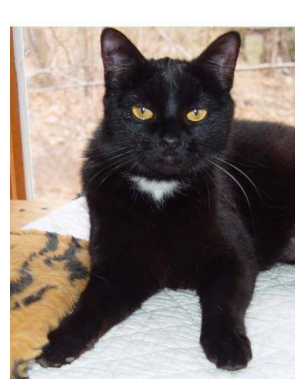

In [22]:
image = Image.open(r"D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set\cats\cat.3626.jpg")
plt.imshow(image)
plt.axis("off")
plt.show()

Image path : D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set\dogs\dog.2111.jpg
Image Class : dogs
Image Height : 374
Image Width : 500


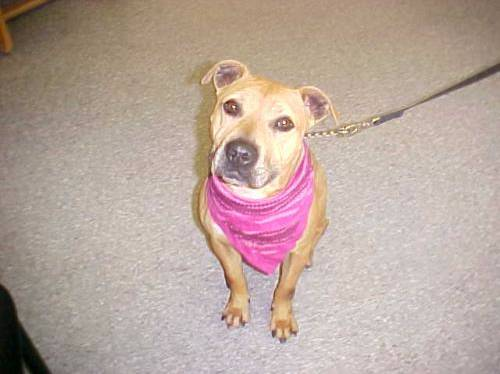

In [23]:
random.seed(42)
image_path_list = glob.glob(
    r'D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set\*/*.jpg'
)
random_image_path = random.choice(image_path_list)
image_class = Path(random_image_path).parent.stem



img = Image.open(random_image_path)
print(f"Image path : {random_image_path}")
print(f"Image Class : {image_class}")
print(f"Image Height : {img.height}")
print(f"Image Width : {img.width}")
img


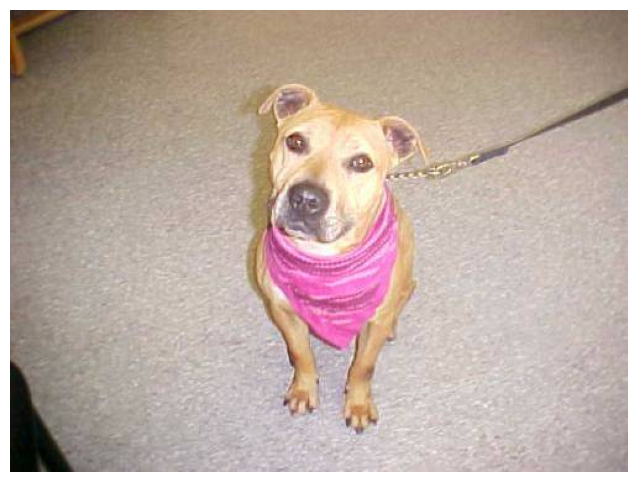

In [24]:
sns.set_theme()
image_to_array = np.array(img)
plt.figure(figsize=(8,6))
plt.imshow(image_to_array)
plt.axis(False)
plt.show()

## Transforming Data

In [25]:
image_width = 128
image_height = 128

image_size = (image_width,image_height)

transform_images = transforms.Compose([
    transforms.Resize(size=image_size),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

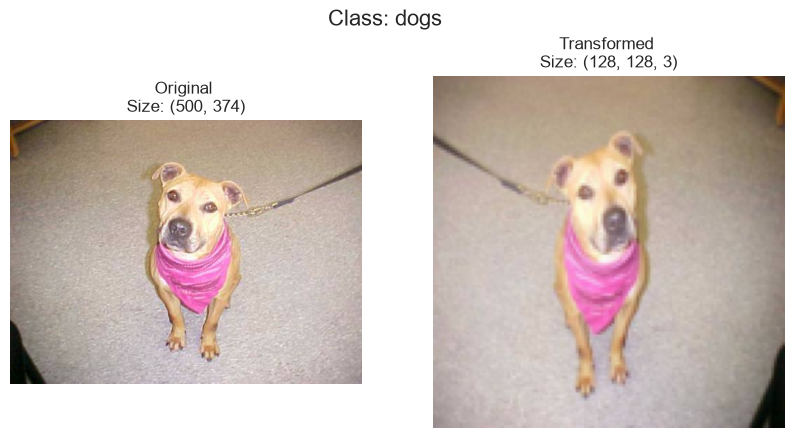

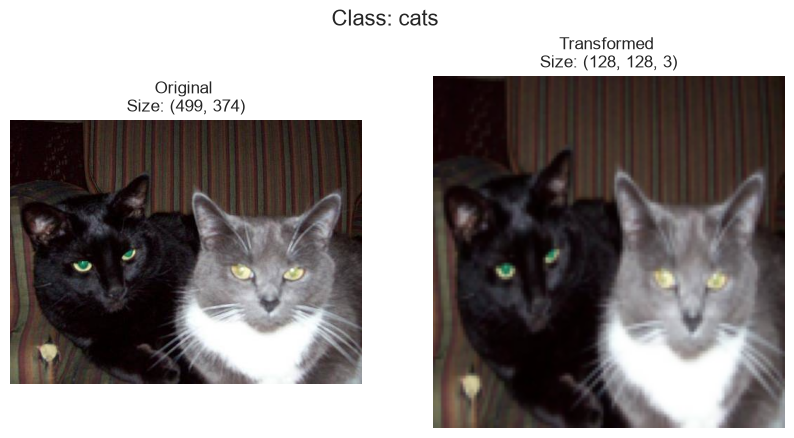

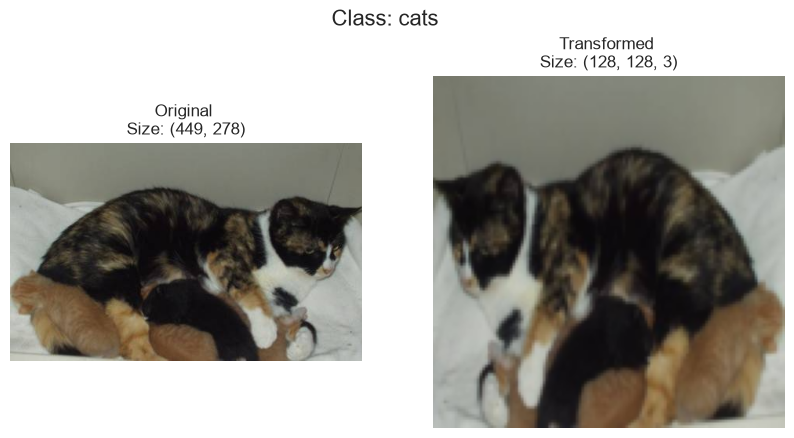

In [26]:

def transform_all_images(image_paths, transform, n=3,seed = 42):
    random.seed(seed)
    sampled_paths = random.sample(image_paths, k=min(n, len(image_paths)))
    for img_path in sampled_paths:
        with Image.open(img_path) as f:
            fig, ax = plt.subplots(1, 2, figsize=(10, 5))
            ax[0].imshow(f)
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            transformed = transform(f)  
            transformed = transformed.permute(1, 2, 0).numpy()  
            ax[1].imshow(transformed)
            ax[1].set_title(f"Transformed \nSize: {transformed.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {Path(img_path).parent.stem}", fontsize=16)
            plt.show()

transform_all_images(image_path_list, transform=transform_images, n=3)

##  Loading Image Data

In [27]:
train_data = datasets.ImageFolder(root=train_dir, transform=transform_images,target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=transform_images)
print(f"Train Data {train_data}\n Test Data {test_data}")

Train Data Dataset ImageFolder
    Number of datapoints: 8005
    Root location: D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\training_set\training_set
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )
 Test Data Dataset ImageFolder
    Number of datapoints: 2021
    Root location: D:\Users\DEBJIT DAS\PetVision Classifier\Dataset\test_set\test_set
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [28]:
print(f"Class name : {train_data.classes}")
print(f"Class name : {train_data.class_to_idx}")
print(f"The Lenght of Traning and Test Data Set  :",len(train_data),len(test_data))


Class name : ['cats', 'dogs']
Class name : {'cats': 0, 'dogs': 1}
The Lenght of Traning and Test Data Set  : 8005 2021


In [29]:
img, label = train_data[0]
print(f"Image Tensor: {img}")
print(f"Image Shape: {img.shape}")
print(f"Image DataType: {img.dtype}")
print(f"Image label: {label}")
print(f" Label datatype : {label}")

Image Tensor: tensor([[[0.1569, 0.1608, 0.1608,  ..., 0.6196, 0.7765, 0.7882],
         [0.1529, 0.1490, 0.1490,  ..., 0.6118, 0.7529, 0.7882],
         [0.1490, 0.1333, 0.1333,  ..., 0.6118, 0.7373, 0.7882],
         ...,
         [0.0863, 0.0784, 0.0784,  ..., 0.2392, 0.2627, 0.1725],
         [0.1098, 0.0902, 0.0863,  ..., 0.2196, 0.1804, 0.1725],
         [0.1176, 0.0902, 0.0863,  ..., 0.2431, 0.1804, 0.1765]],

        [[0.1765, 0.1765, 0.1725,  ..., 0.6235, 0.7686, 0.7725],
         [0.1725, 0.1647, 0.1608,  ..., 0.6118, 0.7373, 0.7686],
         [0.1686, 0.1490, 0.1451,  ..., 0.6039, 0.7137, 0.7608],
         ...,
         [0.0784, 0.0706, 0.0706,  ..., 0.1725, 0.2078, 0.1255],
         [0.1020, 0.0824, 0.0784,  ..., 0.1569, 0.1255, 0.1255],
         [0.1098, 0.0824, 0.0784,  ..., 0.1804, 0.1255, 0.1373]],

        [[0.1608, 0.1765, 0.1922,  ..., 0.5843, 0.6706, 0.6431],
         [0.1569, 0.1647, 0.1804,  ..., 0.5804, 0.6471, 0.6510],
         [0.1529, 0.1490, 0.1647,  ..., 0.58

In [30]:

num_of_workers = os.cpu_count()
train_loader = DataLoader(train_data,batch_size=32,shuffle=True,num_workers=num_of_workers)
test_loader = DataLoader(test_data,batch_size=32,shuffle=False,num_workers=num_of_workers)
train_loader,test_loader

(<torch.utils.data.dataloader.DataLoader at 0x2b795cbe010>,
 <torch.utils.data.dataloader.DataLoader at 0x2b795568590>)

In [31]:
img, label = next(iter(train_loader))
print(f"Image shape {img.shape}")
print(f"Label shape: {label}")

Image shape torch.Size([32, 3, 128, 128])
Label shape: tensor([1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
        1, 1, 1, 0, 1, 1, 0, 1])


## Model Building with Data Augmentation

In [32]:
image_height = 224
image_width = 224 
image_size = (image_height,image_width) 

train_augmentation = transforms.Compose(
    [
       transforms.Resize(size= image_size),
       transforms.TrivialAugmentWide(),
       transforms.ToTensor() 
    ]
)
test_augmentation = transforms.Compose(
    [
       transforms.Resize(size= image_size),
       transforms.ToTensor() 
    ]
)

In [33]:
train_data_augmentation = datasets.ImageFolder(train_dir,transform=train_augmentation)
test_data_augmentation = datasets.ImageFolder(test_dir,transform=test_augmentation)

In [34]:
torch.manual_seed(42)

In [35]:
train_augmented_loader = DataLoader(train_data_augmentation,batch_size=32,shuffle=True,num_workers=num_of_workers,pin_memory=True)
test_augmented_loader = DataLoader(test_data_augmentation,batch_size=32,shuffle=False,num_workers=num_of_workers,pin_memory=True)
train_augmented_loader,test_augmented_loader

(<torch.utils.data.dataloader.DataLoader at 0x2b79250b3d0>,
 <torch.utils.data.dataloader.DataLoader at 0x2b795543a90>)

In [41]:
class ImageClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        
        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2)
        )

        
        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2)
        )

       
        self.conv_layer_3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2)
        )

        
        self.conv_layer_4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2)
        )

        
        self.conv_layer_5 = nn.Sequential(
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 2)  
        )

    def forward(self, x):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)
        x = self.conv_layer_3(x)
        x = self.conv_layer_4(x)
        x = self.conv_layer_5(x)

        x = self.classifier(x)

        return x


model = ImageClassifier().to(device)